<a href="https://colab.research.google.com/github/TorbjornLarsson/SCDA/blob/main/Lab3_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab exercise 3: Eigenvalues and SVD

## Part 1: Eigenvalues and SVD in Python

_This part of the lab is an introduction to eigenvalues, eigenvectors, singular values and SVD in Python. Whereas you probably worked with eigenvalues/eigenvectors before, singular values and SVD is probably new._

### Eigenvalues - Short Background

A matrix $A$ times vector $x$ is a linear transformation of $x$ that stretches and rotates the vector $x$.
We will begin by getting some intuition for such transformations using a particular matrix $A$.

_1.1) Run the cell below to import the required packages and define the function `plot_vect`. This function can be used to plot two vectors in a coordinate system. The next cell defines a matrix $A$ and vector $x$. Run this cell to plot the vector $x$ together with the linear transformation $Ax$ on the specified domain. Change the vector $x$ a few times to convince yourself that $Ax$ results in stretching and rotating of the vector $x$._

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

def plot_vect(x, b, xlim, ylim):
    '''
    function to plot two vectors,
    x - the original vector
    b - the transformed vector
    xlim - the limit for x
    ylim - the limit for y
    '''
    plt.figure(figsize = (10, 6))
    plt.quiver(0,0,x[0],x[1],\
        color='k',angles='xy',\
        scale_units='xy',scale=1,\
        label='Original vector')
    plt.quiver(0,0,b[0],b[1],\
        color='g',angles='xy',\
        scale_units='xy',scale=1,\
        label ='Transformed vector')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid(True)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.show()

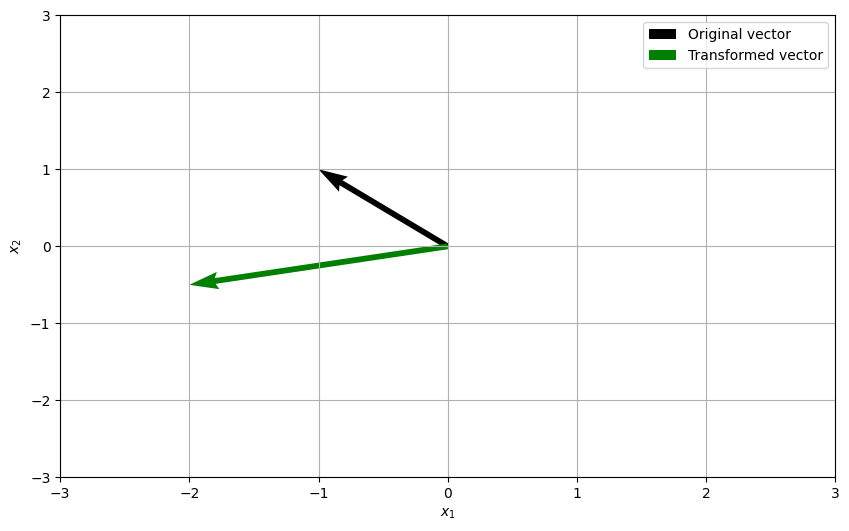

In [5]:
A = np.array([[2, 0],[0, -0.5]])
x = np.array([[-1],[1]])
Ax = A@x
plot_vect(x, Ax, (-3,3), (-3,3))

The matrix used in the previous task is
$
A = \left( \begin{array}{cc}
2 & 0 \\
0 & -0.5
\end{array} \right)
$
with eigenvectors
$
\begin{array}{ll}
v_1 = \left( \begin{array}{c}
0 \\
1
\end{array} \right)
&
v_2 = \left( \begin{array}{c}
1 \\
0
\end{array} \right)
\end{array}.
$

To remind ourselves what an eigenvector is, we will use the matrix $A$ to perform a linear transformation of these eigenvectors.

_1.2) Repeat the previous task, but define the eigenvectors of the matrix $A$ as $x$-vector. In what way is the linear transformation different now (compared to the transformation obtained using any other vector)?_

For eigenvector v1:
Original vector: [0 1]
Transformed vector Av1: [ 0.  -0.5]


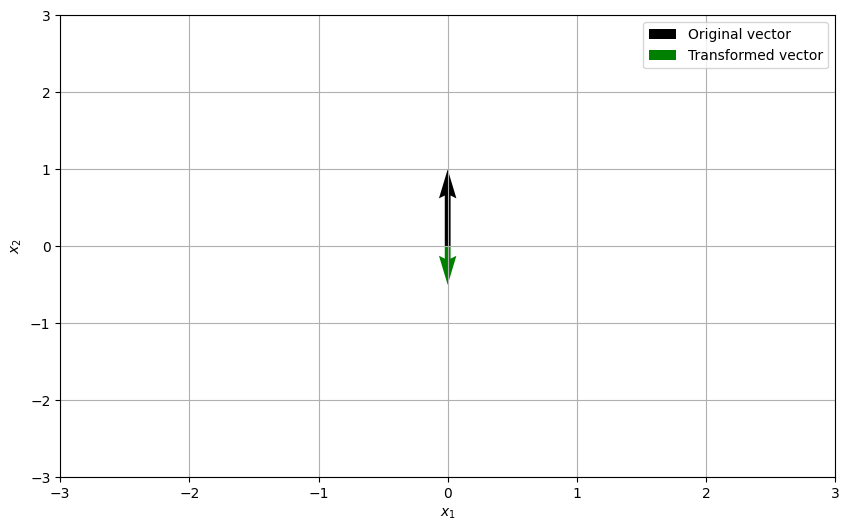


For eigenvector v2:
Original vector: [1 0]
Transformed vector Av2: [2. 0.]


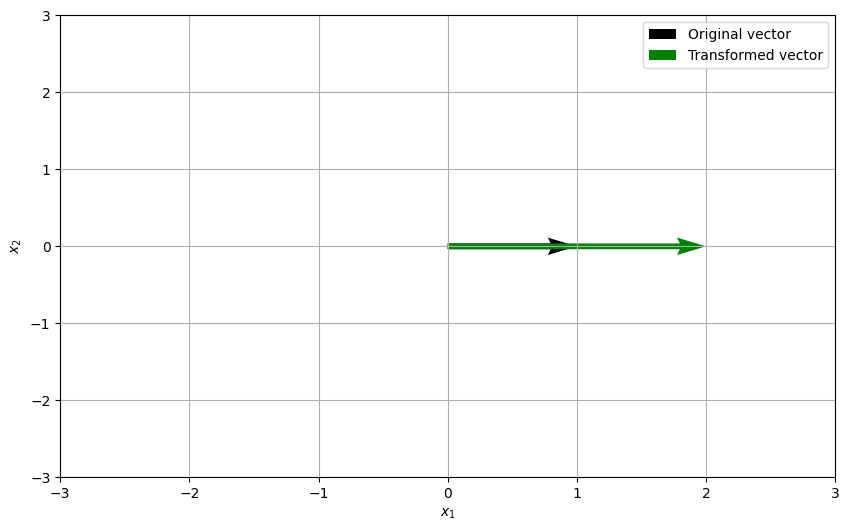

In [6]:
# 1.2) Repeat the previous task, but define the eigenvectors of the matrix  A  as  x -vector. In what way is the linear transformation different now (compared to the transformation obtained using any other vector)?

# Eigenvector 1
v1 = np.array([[0],[1]])
Ax_v1 = A@v1
print("For eigenvector v1:")
print(f"Original vector: {v1.flatten()}")
print(f"Transformed vector Av1: {Ax_v1.flatten()}")
plot_vect(v1, Ax_v1, (-3,3), (-3,3))

# Eigenvector 2
v2 = np.array([[1],[0]])
Ax_v2 = A@v2
print("\nFor eigenvector v2:")
print(f"Original vector: {v2.flatten()}")
print(f"Transformed vector Av2: {Ax_v2.flatten()}")
plot_vect(v2, Ax_v2, (-3,3), (-3,3))


The conclusion is that eigenvectors are vectors in which the transformation only lead to scaling (no rotation), and the scaling factor is the corresponding eigenvalue. This can be written $Av = \lambda v$, which is the eigenvalue problem. Thus, the eigenvalue problem for a matrix $A$ is solved by an eigenvalue $\lambda$, together with the corresponding eigenvector $v$.

_1.3) From the plots you obtained in Task 1.2), what are the eigenvalues of $A$?_

***


In [7]:
#1.3) From the plots you obtained in Task 1.2), what are the eigenvalues of  A ?
# The eigenvalues of A are 2 and -0.5.
# For v1 = [0, 1], Av1 = [0, -0.5], so the eigenvalue is -0.5.
# For v2 = [1, 0], Av2 = [2, 0], so the eigenvalue is 2.


### Eigenvalues and Eigenvectors in Numpy

In numpy, the command `S, V = np.linalg.eig(A)` computes the eigenvalues/eigenvectors of the matrix $A$, where $S$ is a vector with A's eigenvalues and $V$ is a matrix containing the corresponding eigenvectors stored as columns. The eigenvectors are always normalized (unit length). <br>

_2.1) Use `np.linalg.eig` to find the eigenvalues and eigenvectors of the matrix_

a) $A =\left( \begin{array}{cc}
 2 & 0 \\
 0 & -0.5
 \end{array} \right)$ (the marix used above)
 <br><br>
b) $B =\left( \begin{array}{ccc}
 2 & 3 & 1 \\
 0 & 0.5 & 2 \\
 0 &  0  & 1
 \end{array} \right) $ (Note, the eigenvalues of a triangular matrix are equal to the diagonal elements)
 <br><br>
c) $C =\left( \begin{array}{ccc}
 -1 & 3 & 1 \\
 1 & 0.5 & 2 \\
 1 &  -4  & 5
 \end{array} \right) $ (Note, complex eigenvalues always comes in complex conjugate pairs)


In [8]:
# In numpy, the command S, V = np.linalg.eig(A) computes the eigenvalues/eigenvectors of the matrix  A , where  S  is a vector with A's eigenvalues and  V  is a matrix containing the corresponding eigenvectors stored as columns. The eigenvectors are always normalized (unit length).
#
# 2.1) Use np.linalg.eig to find the eigenvalues and eigenvectors of the matrix
#
# a)  A=(2 0; 0 −0.5)  (the matrix used above)
#
# b)  B=(2 3 1; 0 0.5 2; 0 0 1)  (Note, the eigenvalues of a triangular matrix are equal to the diagonal elements)
#
# c)  C=(-1 3 1; 1 0.5 2; 1 -4 5)  (Note, complex eigenvalues always comes in complex conjugate pairs)

# a) Matrix A
A_matrix_2_1 = np.array([[2, 0], [0, -0.5]])
eigenvalues_A, eigenvectors_A = np.linalg.eig(A_matrix_2_1)
print("\n--- Matrix A ---")
print("Eigenvalues of A:", eigenvalues_A)
print("Eigenvectors of A:\n", eigenvectors_A)

# b) Matrix B
B_matrix = np.array([[2, 3, 1], [0, 0.5, 2], [0, 0, 1]])
eigenvalues_B, eigenvectors_B = np.linalg.eig(B_matrix)
print("\n--- Matrix B ---")
print("Eigenvalues of B:", eigenvalues_B)
print("Eigenvectors of B:\n", eigenvectors_B)

# c) Matrix C
C_matrix = np.array([[-1, 3, 1], [1, 0.5, 2], [1, -4, 5]])
eigenvalues_C, eigenvectors_C = np.linalg.eig(C_matrix)
print("\n--- Matrix C ---")
print("Eigenvalues of C:", eigenvalues_C)
print("Eigenvectors of C:\n", eigenvectors_C)



--- Matrix A ---
Eigenvalues of A: [ 2.  -0.5]
Eigenvectors of A:
 [[1. 0.]
 [0. 1.]]

--- Matrix B ---
Eigenvalues of B: [2.  0.5 1. ]
Eigenvectors of B:
 [[ 1.         -0.89442719 -0.95320625]
 [ 0.          0.4472136   0.29329423]
 [ 0.          0.          0.07332356]]

--- Matrix C ---
Eigenvalues of C: [-1.86486172+0.j          3.18243086+1.65581423j  3.18243086-1.65581423j]
Eigenvectors of C:
 [[ 0.94946797+0.j         -0.28699326+0.38749443j -0.28699326-0.38749443j]
 [-0.19059771+0.j         -0.38453126+0.38182038j -0.38453126-0.38182038j]
 [-0.24936537+0.j         -0.68835445+0.j         -0.68835445-0.j        ]]


According to _the spectral theorem_, a symmetric $n\times n$-matrix $A$ always has $n$ distinct and real eigenvalues and the associated eigenvectors are orthogonal. Thus, for an eigenvalue $\lambda_i$ of a symmetric matrix $A$ with corresponding eigenvector $v_i$, it holds that $Av_i=\lambda_i v_i$ for each $i$, so that $Av_1=\lambda_1 v_1, \ldots , Av_n = \lambda_n v_n$, where the $v_i's$ are orthogonal. If we put $v_i$ into a matrix we can write <br>
$$
A \left( \begin{array}{ccc}
  & & \\
 v_1& \cdots & v_n \\
  & &
  \end{array} \right) = \left( \begin{array}{ccc}
  & & \\
 v_1& \cdots & v_n \\
  & &
  \end{array} \right)
  \left( \begin{array}{ccc}
  \lambda_1& & \\
   & \ddots &  \\
  & & \lambda_n
  \end{array} \right) \Rightarrow AV = V D.
$$
<br>

Thus, since the eigenvectors are orthogonal, it holds that $V^TV = VV^T = I$, where $I$ is the identity matrix. The matrix $V$ is said to be orthogonal.

_2.2) Check that this is true for a couple of symmetric matrices, i.e. check that the matrix has $n$ distrinct eigenvalues and that the corresponding eigenvectors are orthogonal using the method described above. You can for example use the matrices:
 <br><br>
a) $A =\left( \begin{array}{ccc}
 2 & 3 & 1 \\
 3 & 0.5 & 2 \\
 1 &  2  & 1
 \end{array} \right) $ <br><br>
b) $C = B^TB$, where $B =\left( \begin{array}{ccc}
 -1 & 3 & 1 \\
 1 & 0.5 & 2 \\
 1 &  -4  & 5
 \end{array} \right) $._ <br>


In [10]:
# 2.2) Check that this is true for a couple of symmetric matrices, i.e. check that the matrix has  n  distrinct eigenvalues and that the corresponding eigenvectors are orthogonal using the method described above. You can for example use the matrices:
# a)  A=(2 3 1; 3 0.5 2; 1 2 1)
# b)  C=B^TB , where  B=(-1 3 1; 1 0.5 2; 1 -4 5)

import numpy as np

# a) Matrix A
A_symmetric = np.array([[2, 3, 1], [3, 0.5, 2], [1, 2, 1]])

print("--- Symmetric Matrix A ---")
print("Matrix A:\n", A_symmetric)

eigenvalues_A_symm, eigenvectors_A_symm = np.linalg.eig(A_symmetric)

print("Eigenvalues of A:", eigenvalues_A_symm)
print("Eigenvectors of A:\n", eigenvectors_A_symm)

# Check if eigenvalues are real (for symmetric matrices, they should be)
print("Are eigenvalues real?:", np.all(np.isreal(eigenvalues_A_symm)))

# Check for orthogonality of eigenvectors
# For orthogonal matrix V, V.T @ V should be identity matrix
orthogonality_check_A = eigenvectors_A_symm.T @ eigenvectors_A_symm
print("Orthogonality check for A (V.T @ V, should be close to Identity):\n", orthogonality_check_A)

# Check if it's close to identity matrix within a tolerance
print("Are eigenvectors of A orthogonal (close to identity)?:",
      np.allclose(orthogonality_check_A, np.identity(A_symmetric.shape[0])))


# b) Matrix C = B^TB
B_matrix_2_2 = np.array([[-1, 3, 1], [1, 0.5, 2], [1, -4, 5]])
C_symmetric = B_matrix_2_2.T @ B_matrix_2_2

print("\n--- Symmetric Matrix C = B^TB ---")
print("Matrix B:\n", B_matrix_2_2)
print("Matrix C:\n", C_symmetric)

eigenvalues_C_symm, eigenvectors_C_symm = np.linalg.eig(C_symmetric)

print("Eigenvalues of C:", eigenvalues_C_symm)
print("Eigenvectors of C:\n", eigenvectors_C_symm)

# Check if eigenvalues are real (for symmetric matrices, they should be)
print("Are eigenvalues real?:", np.all(np.isreal(eigenvalues_C_symm)))

# Check for orthogonality of eigenvectors
orthogonality_check_C = eigenvectors_C_symm.T @ eigenvectors_C_symm
print("Orthogonality check for C (V.T @ V, should be close to Identity):\n", orthogonality_check_C)

# Check if it's close to identity matrix within a tolerance
print("Are eigenvectors of C orthogonal (close to identity)?:",
      np.allclose(orthogonality_check_C, np.identity(C_symmetric.shape[0])))


--- Symmetric Matrix A ---
Matrix A:
 [[2.  3.  1. ]
 [3.  0.5 2. ]
 [1.  2.  1. ]]
Eigenvalues of A: [ 5.31594878  0.38466894 -2.20061772]
Eigenvectors of A:
 [[-0.67293965 -0.55514786  0.48883849]
 [-0.59927113  0.0217602  -0.80025034]
 [-0.43362004  0.83146698  0.34732739]]
Are eigenvalues real?: True
Orthogonality check for A (V.T @ V, should be close to Identity):
 [[ 1.00000000e+00 -1.11022302e-16  3.33066907e-16]
 [-1.11022302e-16  1.00000000e+00 -3.33066907e-16]
 [ 3.33066907e-16 -3.33066907e-16  1.00000000e+00]]
Are eigenvectors of A orthogonal (close to identity)?: True

--- Symmetric Matrix C = B^TB ---
Matrix B:
 [[-1.   3.   1. ]
 [ 1.   0.5  2. ]
 [ 1.  -4.   5. ]]
Matrix C:
 [[  3.    -6.5    6.  ]
 [ -6.5   25.25 -16.  ]
 [  6.   -16.    30.  ]]
Eigenvalues of C: [45.61418662  1.09408677 11.54172661]
Eigenvectors of C:
 [[ 0.20212111 -0.97509322 -0.09132507]
 [-0.64413765 -0.20260045  0.7375905 ]
 [ 0.737722    0.09025669  0.66904408]]
Are eigenvalues real?: True
Orthog


The relations you have seen above, $AV = V D$ together with $V^TV = VV^T = I$, lead to an important result, namely <i>the eigendecomposition</i> of $A$: $A = V D V^T$.

### The singular value decomposition (SVD)

Eigenvalues and eigenvectors require square matrices. What can be done when the matrix $A$ is non-square, for example an over-determined system (more rows than columns)?<br>
We can work with $A^TA$ and $AA^T$ instead. These are always symmetric and we can therefore find the eigendemposition.

_3.1) Define the matrix_
$A =\left( \begin{array}{ccc}
 2 & 3 & 1 \\
 3 & 0.5 & 2 \\
 1 &  2  & 1 \\
 0 & 1 & 2
 \end{array} \right) $
 _and compute the eigenvalues and eigenvectors of $A^TA$ and $AA^T$, respectively. Compare the eigenvalues of the two matrices. Are they similar in any way?_

In [11]:
# 3.1) Define the matrix A and compute the eigenvalues and eigenvectors of A.T@A and A@A.T, respectively. Compare the eigenvalues of the two matrices. Are they similar in any way?

import numpy as np

# Define matrix A as given in Task 3.1
A = np.array([[2, 3, 1],
              [3, 0.5, 2],
              [1, 2, 1],
              [0, 1, 2]])

print("Matrix A:\n", A)

# Compute A.T@A
ATA = A.T @ A
print("\nMatrix A.T@A:\n", ATA)

# Compute eigenvalues and eigenvectors of A.T@A
eigenvalues_ATA, _ = np.linalg.eig(ATA)
print("Eigenvalues of A.T@A:", eigenvalues_ATA)

# Compute A@A.T
AAT = A @ A.T
print("\nMatrix A@A.T:\n", AAT)

# Compute eigenvalues and eigenvectors of A@A.T
eigenvalues_AAT, _ = np.linalg.eig(AAT)
print("Eigenvalues of A@A.T:", eigenvalues_AAT)

print("\nComparison of non-zero eigenvalues:")
print("Eigenvalues of A.T@A (sorted, real parts):", np.sort(np.real(eigenvalues_ATA)))
print("Eigenvalues of A@A.T (sorted, real parts):", np.sort(np.real(eigenvalues_AAT)))


Matrix A:
 [[2.  3.  1. ]
 [3.  0.5 2. ]
 [1.  2.  1. ]
 [0.  1.  2. ]]

Matrix A.T@A:
 [[14.    9.5   9.  ]
 [ 9.5  14.25  8.  ]
 [ 9.    8.   10.  ]]
Eigenvalues of A.T@A: [30.63189054  2.75264907  4.86546039]

Matrix A@A.T:
 [[14.    9.5   9.    5.  ]
 [ 9.5  13.25  6.    4.5 ]
 [ 9.    6.    6.    4.  ]
 [ 5.    4.5   4.    5.  ]]
Eigenvalues of A@A.T: [3.06318905e+01 1.16001369e-16 2.75264907e+00 4.86546039e+00]

Comparison of non-zero eigenvalues:
Eigenvalues of A.T@A (sorted, real parts): [ 2.75264907  4.86546039 30.63189054]
Eigenvalues of A@A.T (sorted, real parts): [1.16001369e-16 2.75264907e+00 4.86546039e+00 3.06318905e+01]


You should have noted that $A^TA$ and $AA^T$ have the same non-zero eigenvalues (they might come in different order, though), and the remaining eigenvalues are zero. This is always the case. Now, we will compare the results with a decomposition called the _Singular Value Decomposition (SVD)_. The SVD of a matrix $A$ is defined as $A=U \Sigma V^T$, where $U$ is a matrix containing the so-called left singular vectors of $A$ in its columns, $V$ is a matrix containing the right singular vectors of $A$ in its columns, and $\Sigma$ is a diagonal matrix defined as below, containing the singular values of $A$, $\sigma_i$, along its diagonal:
$$
\Sigma = \left( \begin{array}{ccc} \sigma_1 & & \\ & \ddots & \\ &  & \sigma_n \end{array} \right)
$$

_3.2) What does the SVD of $A$ have to do with the matrices $A^TA$ and $AA^T$? The code snippet below calculates the SVD of the matrix $A$ (the same matrix $A$ as in Task 3.1). Run the cell and compare the SVD with eigenvalues and eigenvectors of $A^TA$ and $AA^T$ you found in the previous task. What similarities do you find?_

In [13]:
U, S, Vt = np.linalg.svd(A, full_matrices=True)   # The SVD of A, singular values in S
V = np.transpose(Vt)

print(f'The singular values of A are: {S}')
print('Hint: Look at the square of the singular values!')
print(f'The square of the singular values are: {S**2}')

print('The matrix U:')
print(U)

print('The matrix V:')
print(V)

The singular values of A are: [5.53460844 2.20577886 1.65911093]
Hint: Look at the square of the singular values!
The square of the singular values are: [30.63189054  4.86546039  2.75264907]
The matrix U:
[[-0.6416176   0.45696165  0.368455    0.4937143 ]
 [-0.57133115 -0.81510354  0.08215473 -0.04937143]
 [-0.42088231  0.34251532 -0.03305801 -0.83931431]
 [-0.29114542  0.09734229 -0.92541811  0.22217143]]
The matrix V:
[[-0.61758858 -0.53898059  0.57278641]
 [-0.60409484  0.7914239   0.09336822]
 [-0.50364051 -0.28835417 -0.81436976]]


**Conclusion:** <br>
$A$'s left singular vectors $U$ (columns of U) are equal to the eigenvectors of $AA^T$ (sign might differ)<br>
$A$'s right singular vectors $V$ (columns of V) are equal to the eigenvectors of $A^TA$ (sign might differ)<br>
$A$'s singular values are the square root of $A^TA$'s eigenvalues (or $AA^T$'s nonzero eigenvalues) <br>
<br>
There are many applications where SVD is used (you will see one in the next part of this lab). In data analysis, we often have big non-square matrices with data, and SVD is as an important tool.
